# MACHINE LEARNING

When data is derived from a given data it is called machine learning.

TYPES OF MACHINE LEARNING
- Supervised : in this input and output both are available, from analyzing this data the machine predicts the output of a new input.
    - Regression : when the data of output  is *numerical*
    - Classification : when the  data of output is *categorical*

- Unsupervised : only input is available.so basically no perdications can be made.
    - Clustering : 
        - It makes categories of data. 
        - like basically groups togethere similar values and we can label them as a category. 
        - Very useful when we want to group customers and like understand which types of customer behaves how.
    - Dimensionality Reduction:
        - When there is a lot of input data, like a alot of columns exist and we want to reduce the unecessary or if we want to combine two similar columns we used this.
        - columns = dimensions
        - for example, if we have data of a house without above 1000 dimensions, and i want to reduce the dimensions, lets say there are two columns 'NO. of rooms' 'No. of washrooms'- now what will this Dimensional Reduction techinques do is, since they both are similar it will combine them into one column 'SquareFt area'.
        - Visvualization is not possible for very large data, so we can reduce large data into 2-3 dimensions to help in visulaization too.
    - Anamoly Detection : 
        - Basically outliners are detected and removed
        - example, u have trained a ML bot to see red flags , and it sees a green flag but within the normal range so it will do nthg, but if that green flag goes somewhere outside (outliner) then it is removed or not considered
    - Association rule learning:
        - From the data we MINE for realtions between the products, or basically find realtion between any elements
        - example- walmart, baby daipers and beer.
        - so Association rule learning helps us by finding hidden realtion between elements

- Semi-supervised :
    - here we label some data, and all the other data is automatically labeled
    - For example, a clustering algorithm may be used to group similar instances together, and then every unlabeled instance can be labeled with the most common label in its cluster.
- Reinforcement : Reward and punishment system, there is no data in this machine learning type. It learns from getting reward for the right thing and punishment for the wrong action. Soo when ever it will do a wrong thing the bot with update itself and no do that thing again.



# Feature Scaling



1️⃣ What is a Feature?

A feature is an input variable.

It describes something about the data.

Example in wine dataset:

Alcohol → feature

Malic acid → feature

👉 Features = X (inputs)

2️⃣ What is a Class (Label)?

The class is the output we want to predict.

It is the category or answer.

Example:

Class label (1, 2, 3) → type of wine

👉 Class = y (output)

3️⃣ Why Do We Separate X and y?

X = features (inputs)

y = class (answer)

The model learns patterns from X to predict y.

4️⃣ Train-Test Split

Training data → used to learn

Test data → used to evaluate performance

Test data must stay unseen

Prevents cheating and gives real performance

Example:

70% training

30% testing

5️⃣ Why Do We Scale Features?

Problem:

Different features have different ranges.

Example:

Alcohol: 10–15

Malic acid: 0–5

Larger values dominate distance calculations.

Solution:

Scale features so they have similar range.

Makes learning fair.

6️⃣ What is MinMaxScaler?

MinMaxScaler rescales values between 0 and 1.

Formula:

New Value=(Value−Min)/(Max−Min)

After scaling:

Minimum value becomes 0

Maximum value becomes 1

All other values fall between 0 and 1

7️⃣ What Does scaler = MinMaxScaler() Do?

Creates a scaling object.

No calculation happens yet.

8️⃣ What Does fit() Do?
scaler.fit(X_train)


Learns minimum and maximum values from training data.

Stores them internally.

Does NOT change data.

fit() = learns

9️⃣ What Does transform() Do?
scaler.transform(X_train)


Applies scaling using stored min and max.

Changes values to range 0–1.

transform() = applies learned rule

Does NOT learn anything new.

🔟 Why Fit Only on Training Data?

Test data must stay unseen.

Using test data during fitting causes data leakage.

Data leakage gives unrealistic performance.

Rule:

✔ Fit → only on training
✔ Transform → training + test

1️⃣1️⃣ Does Scaling Change Shape of Data?

No.

Relative positions stay the same.

Only axis values change.

Scaling resizes, does not reshape.

1️⃣2️⃣ When Is Scaling Important?

Very important for:

KNN

SVM

Logistic Regression

Neural Networks

Gradient Descent models

Because they depend on distance or gradients.

1️⃣3️⃣ When Is Scaling Not Very Important?

Not very important for:

Decision Trees

Random Forest

XGBoost

Reason:

Trees are order-based.

They split using conditions like:

Feature > value

Scaling does not change order.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [7]:
df = pd.read_csv('wine_data.csv',header=None,usecols =[0,1,2])
df.columns = ['Class label','Alcohol','Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

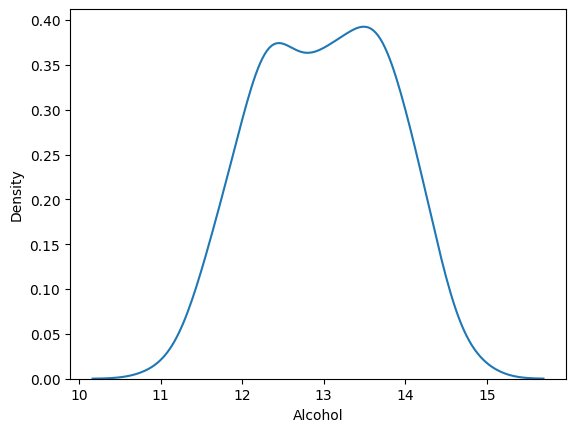

In [ ]:
sns.kdeplot(df['Alcohol']) # kdeplot shows the distribution of the data. It is a smoothed version of the histogram. It is a non-parametric way to estimate the probability density function of a random variable.

<Axes: xlabel='Malic acid', ylabel='Density'>

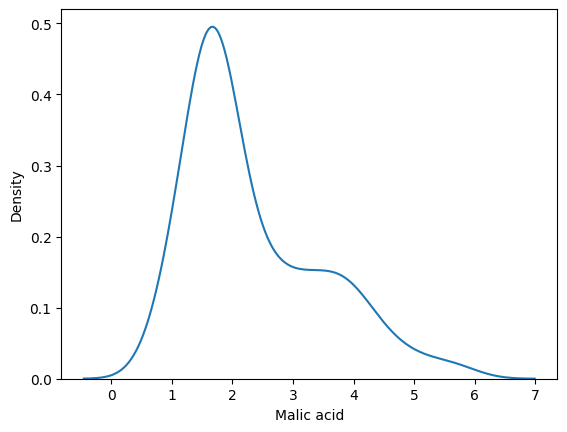

In [9]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

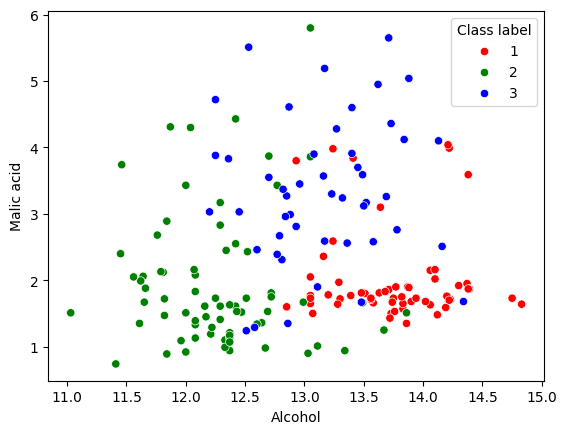

In [10]:
color_dict = {1:'red', 2:'green', 3:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label',axis =1),
                                                    df['Class label'],
                                                    test_size =0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.tranform(X_train)
X_test_scaled = scaler.transform(X_test)
